#Tarefa Avaliativa 1



*   Disciplina: Física com Python 1 (2026.2) — CBPF
*   Autor: Guilherme Rodrigues Bento
*   Obs: Código desenvolvido para fins de avaliação acadêmica. Disponibilizado publicamente sob a Licença MIT para consulta educacional.

##Q1

Aplique o **ridge-plot** (gráfico de cordilheira) para visualizar algum resultado da sua grande área de pesquisa.

**ridge-plot**:
*  https://seaborn.pydata.org/examples/kde_ridgeplot
*  https://python-graph-gallery.com/ridgeline-graph-seaborn/


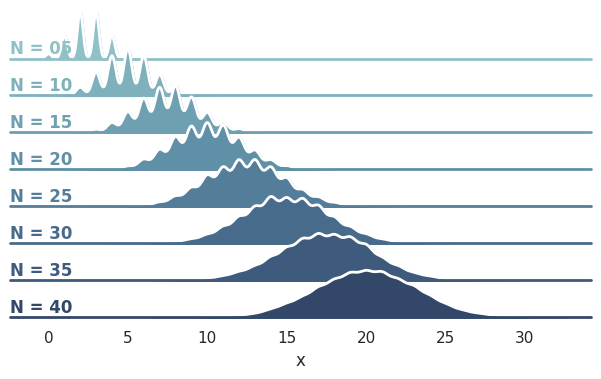

In [1]:
# -------------------- Importing the Packages --------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# -------------------- 1. Simulating the Convergence from Binomial to Normal Distribution --------------------

#np.random.seed(42)

N_values = [5, 10, 15, 20, 25, 30, 35, 40]
p = 0.5

history = []
for N in N_values:
    x = np.random.binomial(n=N, p=p, size=10000)
    history.append(pd.DataFrame({"x": x, "g": f"N = {N:02d}"}))

df = pd.concat(history, ignore_index=True)

# -------------------- 2. Plotting the Graphs --------------------

pal = sns.cubehelix_palette(10, rot=-.25, light=.7)

# Initialize the FacetGrid object
g = sns.FacetGrid(df, row="g", hue="g", aspect=15, height=.5, palette=pal, sharey=False)

# Draw the densities in a few steps
g.map(sns.kdeplot, "x",
      bw_adjust=1.0, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=1.0)

# Passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)


g.map(label, "x")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

plt.show()

##Q2

Aplique o **ternary-plot** (gráfico ternário) para visualizar algum resultado da sua grande área de pesquisa.

**ternary-plot**:
*  https://plotly.com/python/ternary-plots/
*  https://www.geeksforgeeks.org/python/ternary-plots-in-plotly/


In [2]:
# -------------------- Importing the Packages --------------------

import numpy as np
import pandas as pd
from scipy.linalg import expm
import plotly.express as px

# This code represents the evolution in time of the coefficients of probability
# amplitudes of an electron in a 2p orbit in a hydrogen atom with a magnetic
# field in the x-direction

# -------------------- 1. Defining the Initial Scenario --------------------

omega_L = 1.0  # Larmor Frequency


# L_x matrix in the L_z representation
Lx = (1 / np.sqrt(2)) * np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])

# The Hamiltonian of the magnetic interaction
H = omega_L * Lx

# The initial quantum state of the system
psi_0 = np.array([1, 0, 0], dtype=complex) # Represents the state m_l = +1

# Time interval for the system to evolve
tempos = np.linspace(0, 1 * np.pi, 200)

# -------------------- 2. Applying the Dynamics --------------------

# Keeping the history of the probabilities
P_mais1, P_zero, P_menos1 = [], [], []

for t in tempos:
    psi_t = np.dot(expm(-1j * H * t), psi_0)
    probs = np.abs(psi_t)**2

    P_mais1.append(probs[0])
    P_zero.append(probs[1])
    P_menos1.append(probs[2])

# Creating a data frame
df = pd.DataFrame({
    "m_l = +1": P_mais1,
    "m_l = 0": P_zero,
    "m_l = -1": P_menos1,
    "Time": tempos
})

# -------------------- 3. Plotting the Ternary Graph --------------------

fig = px.scatter_ternary(
    df,
    a="m_l = +1",
    b="m_l = 0",
    c="m_l = -1",
    color="Time",  # Add a color gradient to see the time passing
    title="Time Evolution of the p Orbit with Magnetic Field B_x"
)

fig.show()

##Q3

Faça um gráfico com **inset** para visualizar algum resultado da sua grande área de pesquisa.

Exemplo:
https://scipython.com/blog/inset-plots-in-matplotlib/

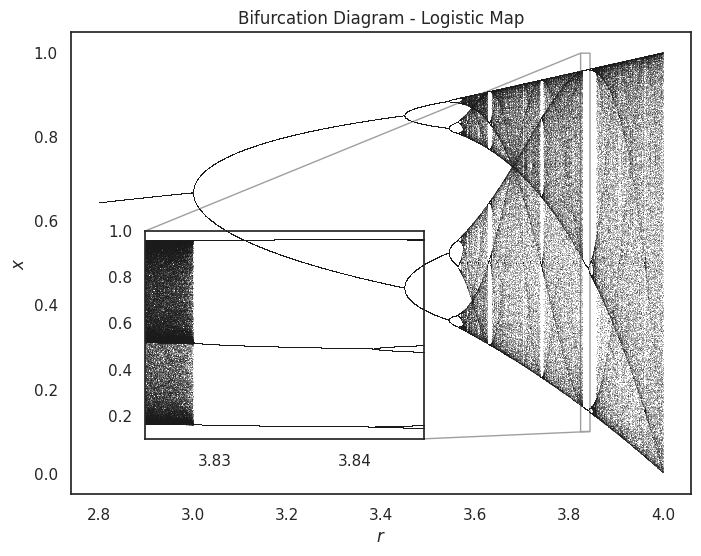

In [3]:
# -------------------- Importing the Packages --------------------

import numpy as np
import matplotlib.pyplot as plt

# -------------------- 1. Generating the Bifurcation Diagram --------------------

# Defining the function for the bifucartion diagram of the logistic map
def bifurcation(r_min, r_max, N, N_ite, N_burn):
    r = np.linspace(r_min, r_max, N)
    x = (1/np.pi) * np.ones(N)

    # Discarding the transient
    for _ in range(N_burn):
        x = r * x * (1 - x)

    r_plot, x_plot = [], []

    # Generating the final orbit
    for _ in range(N_ite):
        x = r * x * (1 - x)
        r_plot.append(r.copy())
        x_plot.append(x.copy())

    return np.array(r_plot).flatten(), np.array(x_plot).flatten()

# Defining some parameters to create an inset graph of the period-3 window
r_main, x_main = bifurcation(2.8, 4.0, 2000, 200, 1000)
r_zoom, x_zoom = bifurcation(3.82, 3.86, 5000, 200, 1000)

# -------------------- 2. Plotting the Graphs --------------------

fig, ax1 = plt.subplots(figsize=(8, 6))

# Plotting the main graph
ax1.plot(r_main, x_main, ',k', alpha=0.25)
ax1.set_xlabel(r'$r$')
ax1.set_ylabel(r'$x$')
ax1.set_title('Bifurcation Diagram - Logistic Map')

# Plotting the inset graph
ax2 = ax1.inset_axes([0.12, 0.12, 0.45, 0.45])
ax2.plot(r_zoom, x_zoom, ',k', alpha=0.3)
ax2.set_xlim(3.825, 3.845)
ax2.set_ylim(0.1, 1.0)
ax2.set_xticks([3.83, 3.84])
ax2.set_xticklabels(ax2.get_xticks(), backgroundcolor='w')
ax2.tick_params(axis='x', which='major', pad=5)

ax1.indicate_inset_zoom(ax2, edgecolor='0.25')

##Q4

Faça um gráfico com **animação** para visualizar dinamicamente algum resultado da sua grande área de pesquisa.


Exemplos: https://python-graph-gallery.com/animation/

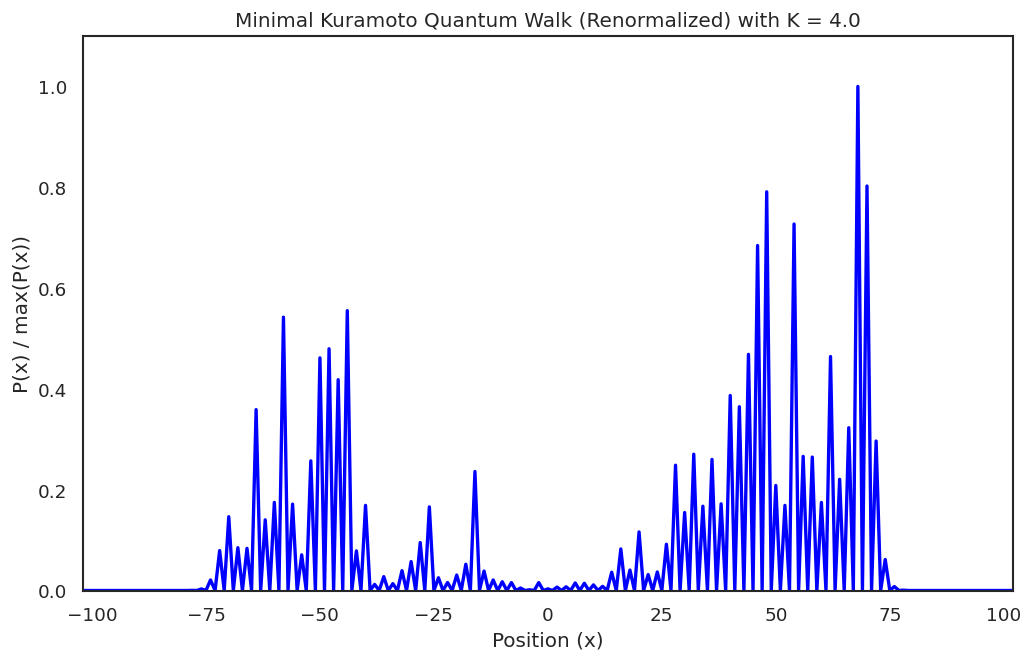

In [4]:
# -------------------- Importing Packages --------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# -------------------- 1. Defining the Initial Scenario --------------------

# Creating the lattice for the walk
tmax  = 100
vtime = np.arange(0, tmax + 1, 1)
vdx   = np.ones(len(vtime), dtype=int)
sumdx = np.sum(vdx)

xpos = np.arange(-int(sumdx) - 1, int(sumdx) + 2, 1)
npos = len(xpos)
xc   = npos // 2

# Defining the Initial Quantum State
BetaBloch = np.radians(90)
AlphaBloch = np.radians(90)

# Creating the Coin Operator
coin = np.zeros((npos, 2, 2), dtype=np.complex128)

# Initial Conditions for the Phases
theta_0 = np.pi / 4
theta_r = np.pi / 4
theta_l = -theta_r
phi = 0

theta = theta_0 * np.ones(npos, dtype=float)
theta[xc + 1] = theta_r
theta[xc - 1] = theta_l

# Establishing the Initial Probability Distribution
vecA1 = np.zeros(npos, dtype=np.complex128)
vecB1 = np.zeros(npos, dtype=np.complex128)
vecA1[xc] = np.cos(BetaBloch / 2)
vecB1[xc] = np.sin(BetaBloch / 2) * np.exp(1j * AlphaBloch)

# Defining the Coin Operator
def KQW_two_oscillators(theta, K, phi, dx, vecA1, vecB1):
    theta[xc + 1] = (theta[xc + 1] - (K / 2) * np.sin(2 * theta[xc + 1])) % (2 * np.pi)
    theta[xc - 1] = -theta[xc + 1]
    phi_c = np.radians(phi)

    coin[:, 0, 0] = np.cos(theta)
    coin[:, 0, 1] = np.exp(1j * phi_c) * np.sin(theta)
    coin[:, 1, 0] = np.exp(-1j * phi_c) * np.sin(theta)
    coin[:, 1, 1] = -1 * np.cos(theta)

    veci = range(dx, npos - dx, 1)
    vecAA1 = coin[veci - dx, 0, 0] * vecA1[veci - dx] + coin[veci - dx, 0, 1] * vecB1[veci - dx]
    vecBB1 = coin[veci + dx, 1, 0] * vecA1[veci + dx] + coin[veci + dx, 1, 1] * vecB1[veci + dx]

    vecAA1 = np.concatenate((np.zeros(dx), vecAA1, np.zeros(dx)), axis=None)
    vecBB1 = np.concatenate((np.zeros(dx), vecBB1, np.zeros(dx)), axis=None)

    return theta, vecAA1, vecBB1

# -------------------- 2. Applying the Dynamics --------------------

# Establishing the value for K
K_val = 4.0

# Renormalizing the Initial Probability Distribution
vpQW = abs(vecA1)**2 + abs(vecB1)**2
vpQW1 = vpQW / np.max(vpQW)

# Keeping the history of the probability
history_P = [vpQW1]

for t in np.arange(1, len(vtime), 1):
    theta, vecA1, vecB1 = KQW_two_oscillators(theta, K=K_val, phi=phi, dx=vdx[t], vecA1=vecA1, vecB1=vecB1)

    # Renormalizing the Probability in each step
    vpQW = abs(vecA1)**2 + abs(vecB1)**2
    vpQW1 = vpQW / np.max(vpQW)
    history_P.append(vpQW1)

History_P_array = np.array(history_P)

# -------------------- 3. Plotting the Animated Graph ----------------------

fig_2d, ax_2d = plt.subplots(figsize=(10, 6), dpi=120)
linha, = ax_2d.plot([], [], lw=2, color='blue')

ax_2d.set_xlim(xpos[0], xpos[-1])
ax_2d.set_ylim(0, 1.1)
ax_2d.set_title(f"Minimal Kuramoto Quantum Walk (Renormalized) with K = {K_val}")
ax_2d.set_xlabel("Position (x)")
ax_2d.set_ylabel("P(x) / max(P(x))")

def update_2d(frame):
    linha.set_data(xpos, History_P_array[frame])
    return [linha]

ani_2d = FuncAnimation(fig_2d, update_2d, frames=len(vtime), interval=50, blit=True)
ani_2d.save("mKQW_K_4.gif", fps=10)

##Q5
Acesse a documentação do [scipy-stats](https://docs.scipy.org/doc/scipy/reference/stats.html) em seguida:

* Escolha 6 distribuições de [variáveis continuas](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions)  que permitam discutir graficamente a **variância**, **skewness** e **kurtosis** de modo representativo. **Organize os paineis em grid 2x3 usando  [plt.subplots(nrows=2, ncols=3, figsize=(15, 8))](https://www.geeksforgeeks.org/data-visualization/how-to-generate-subplots-with-pythons-matplotlib/)**. Coloque no *título* de cada painel o valor da variância, skewness e kurtosis.


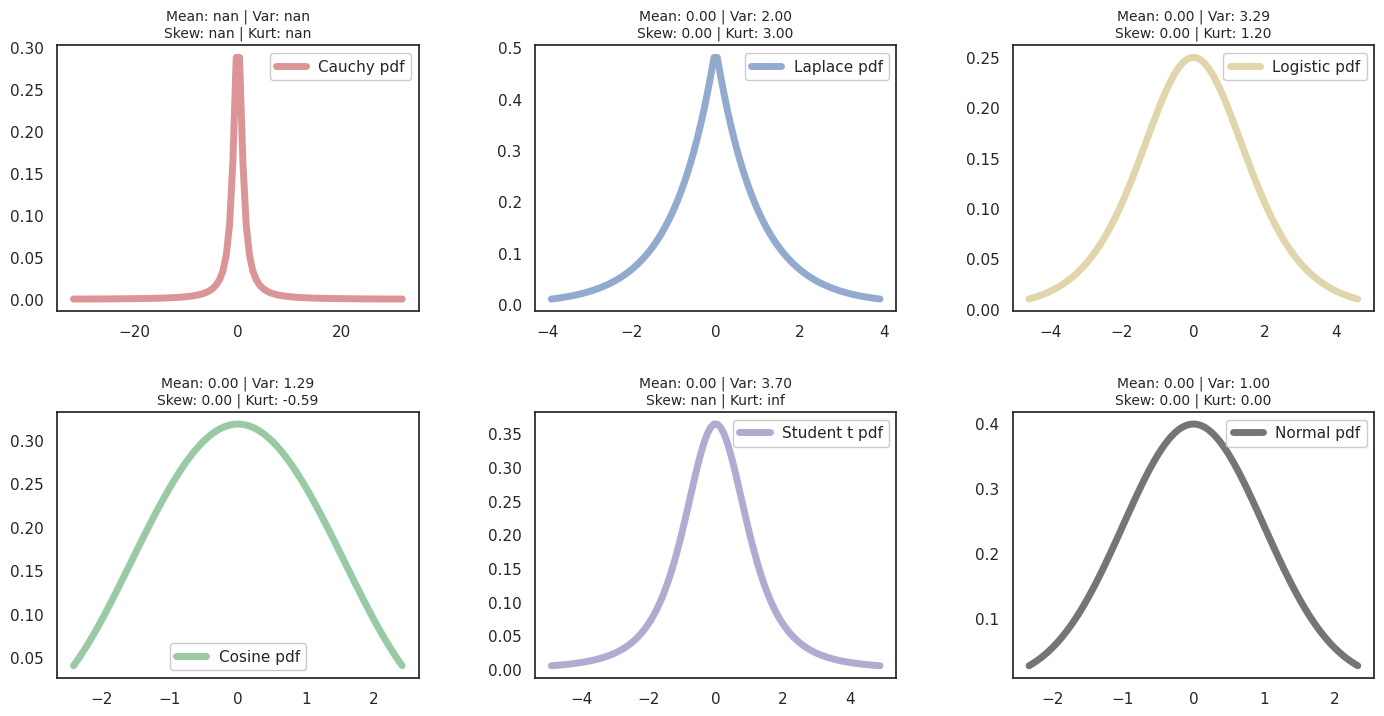

In [6]:
# -------------------- Importing Packages --------------------

import numpy as np
from scipy.stats import cauchy, laplace, logistic, cosine, t, norm
import matplotlib.pyplot as plt

df_t = 2.74

# -------------------- 1. Choosing the Probability Distribution Functions (PDFs) --------------------

# Establishing the pdfs, arguments, colors and titles for the final plot
distributions = [
    (cauchy, {}, 'r-', 'Cauchy'),
    (laplace, {}, 'b-', 'Laplace'),
    (logistic, {}, 'y-', 'Logistic'),
    (cosine, {}, 'g-', 'Cosine'),
    (t, {'df': df_t}, 'm-', 'Student t'),
    (norm, {}, 'k-', 'Normal')
]

# -------------------- 2. Plotting the PDFs --------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.tight_layout(pad=4.0)

for ax, (dist, kwargs, color, name) in zip(axes.flat, distributions):
  # Creating the pdfs and their graphs
    x = np.linspace(dist.ppf(0.01, **kwargs), dist.ppf(0.99, **kwargs), 100)
    ax.plot(x, dist.pdf(x, **kwargs), color, lw=5, alpha=0.6, label=f"{name} pdf")
    ax.legend(loc='best',facecolor='white', framealpha=1.0)

    # Calculating the statistical moments
    m, v, s, k = dist.stats(**kwargs, moments='mvsk')
    ax.set_title(
        f"Mean: {m:.2f} | Var: {v:.2f}\n"
        f"Skew: {s:.2f} | Kurt: {k:.2f}",
        fontsize=10
    )